In [139]:
import pandas as pd
from sklearn import datasets

diabetes = datasets.load_diabetes()
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [140]:
df['dp'] = diabetes.target # dp = diabetic progression (diyabet ilerlemesi/hastalık ilerlemesi)
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6     dp  
0 -0.002592  0.019907 -0.017646  151.0  
1 -0.039493 -0.068332 -0.092204   75.0  
2 -0.002592  0.002861 -0.025930  141.0  
3  0.034309  0.022688 -0.009362  206.0  
4 -0.002592 -0.031988 -0.046641  135.0  


In [141]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
label = 'dp'

X, y = df[features].values, df[label].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set boyutu: {X_train.shape[0]}")
print(f"Test set boyutu: {X_test.shape[0]}")

Train set boyutu: 353
Test set boyutu: 89


In [142]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [143]:
mse = mean_squared_error(y_test, pred)
print(f"Mean Squared Error: {mse:.3f}")
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.3f} ({rmse/np.mean(pred)*100:.3f}%)")
r2 = r2_score(y_test, pred)
print(f"R^2 Skoru: {r2:.3f}")

Mean Squared Error: 2900.194
Root Mean Squared Error: 53.853 (37.962%)
R^2 Skoru: 0.453


In [144]:
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"pred shape: {pred.shape}")

X_test shape: (89, 10)
y_test shape: (89,)
pred shape: (89,)


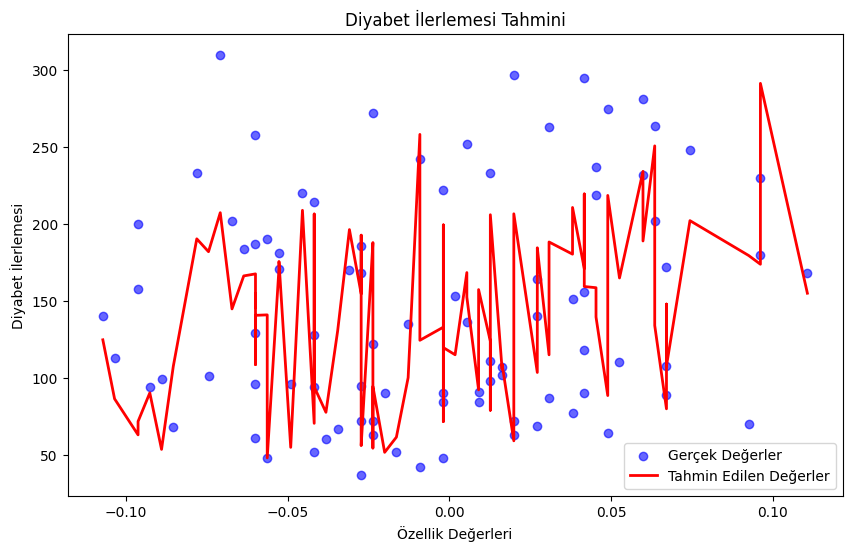

In [145]:
# Verileri X_test[:, 0]'a göre sıralayın
sorted_indices = np.argsort(X_test[:, 0])
X_sorted = X_test[sorted_indices, 0]
y_sorted = y_test[sorted_indices]
pred_sorted = pred[sorted_indices]

plt.figure(figsize=(10, 6))
plt.scatter(X_sorted, y_sorted, color='blue', label='Gerçek Değerler', alpha=0.6)
plt.plot(X_sorted, pred_sorted, color='red', label='Tahmin Edilen Değerler', linewidth=2)
plt.xlabel('Özellik Değerleri')
plt.ylabel('Diyabet İlerlemesi')
plt.title('Diyabet İlerlemesi Tahmini')
plt.legend()
plt.show()

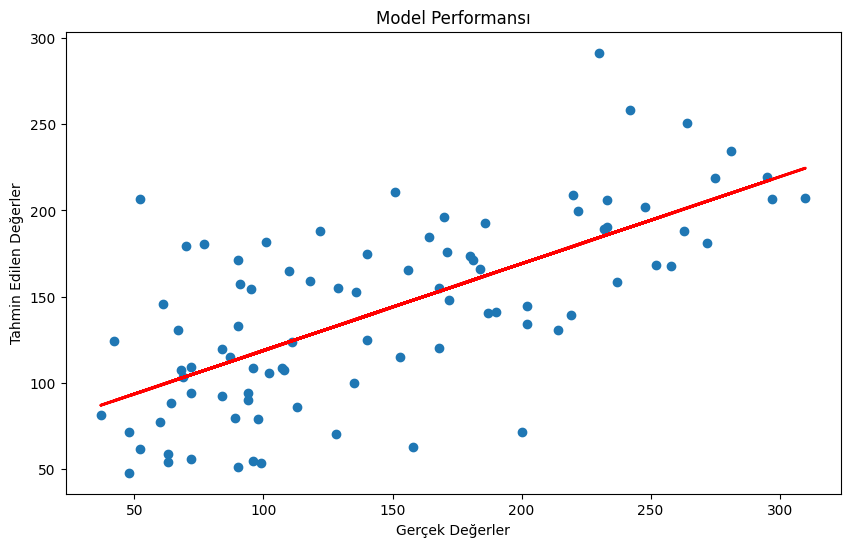

In [146]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred)
z = np.polyfit(y_test, pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linewidth=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Model Performansı')
plt.show()

In [147]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor().fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.3f}")
rmse_rf = np.sqrt(mse_rf)
print(f"Random Forest Root Mean Squared Error: {rmse_rf:.3f} ({rmse_rf/np.mean(pred_rf)*100:.3f}%)")
r2_rf = r2_score(y_test, pred_rf)
print(f"Random Forest R^2 Skoru: {r2_rf:.3f}")

Random Forest Mean Squared Error: 3112.945
Random Forest Root Mean Squared Error: 55.794 (38.497%)
Random Forest R^2 Skoru: 0.412


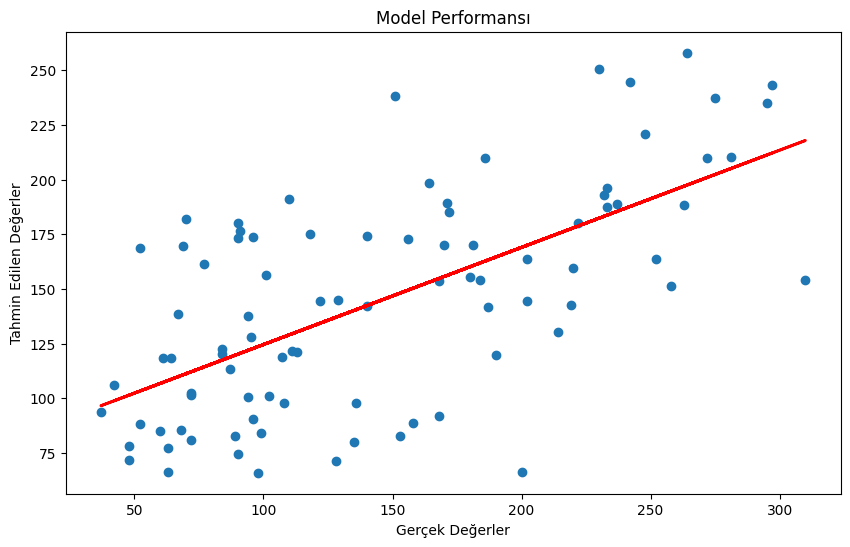

In [148]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_rf)
z = np.polyfit(y_test, pred_rf, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linewidth=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Model Performansı')
plt.show()

In [149]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
pipeline.fit(X_train, y_train)
pred_poly = pipeline.predict(X_test)

mse_poly = mean_squared_error(y_test, pred_poly)
print(f"Polynomial Regression Mean Squared Error: {mse_poly:.3f}")
rmse_poly = np.sqrt(mse_poly)
print(f"Polynomial Regression Root Mean Squared Error: {rmse_poly:.3f} ({rmse_poly/np.mean(pred_poly)*100:.3f}%)")
r2_poly = r2_score(y_test, pred_poly)
print(f"Polynomial Regression R^2 Skoru: {r2_poly:.3f}")

Polynomial Regression Mean Squared Error: 3096.028
Polynomial Regression Root Mean Squared Error: 55.642 (37.306%)
Polynomial Regression R^2 Skoru: 0.416


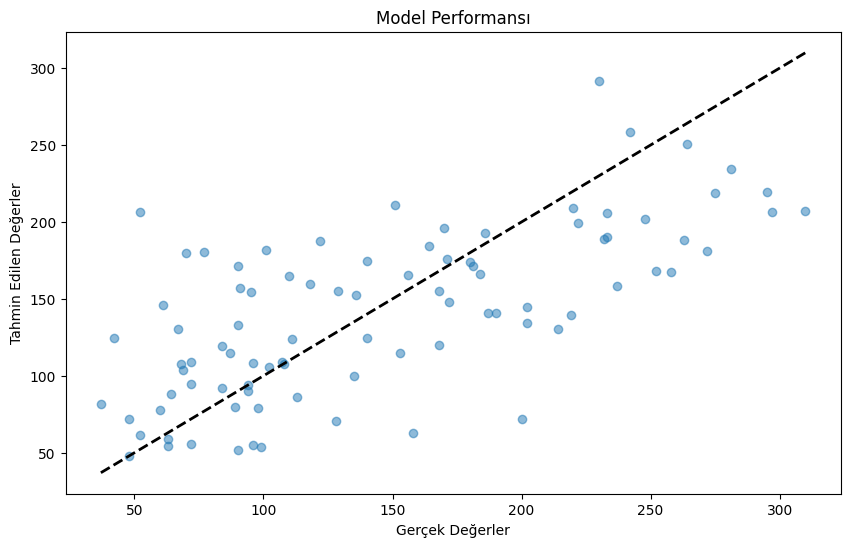

In [150]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Model Performansı')
plt.show()

Ridge Regression Mean Squared Error: 3077.416
Ridge Regression Root Mean Squared Error: 55.474 (37.915%)
Ridge Regression R^2 Skoru: 0.419


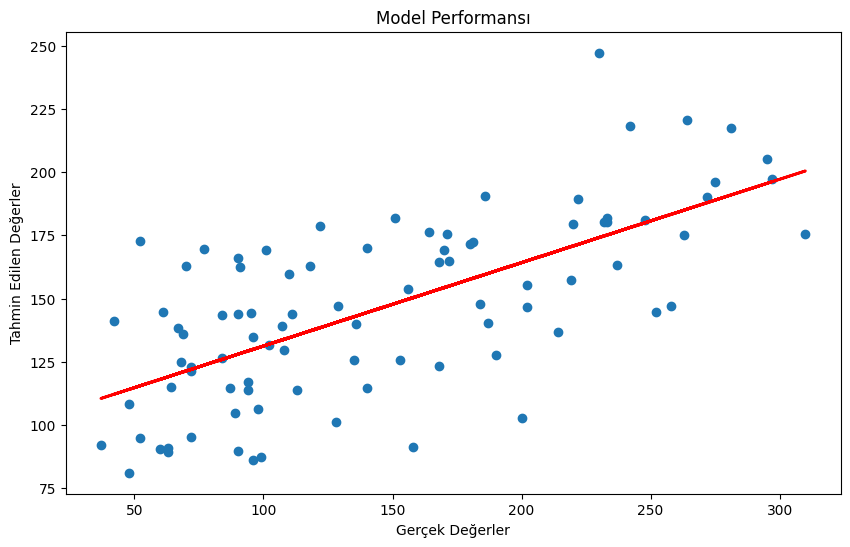

In [151]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0).fit(X_train, y_train)
pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, pred_ridge)
print(f"Ridge Regression Mean Squared Error: {mse_ridge:.3f}")
rmse_ridge = np.sqrt(mse_ridge)
print(f"Ridge Regression Root Mean Squared Error: {rmse_ridge:.3f} ({rmse_ridge/np.mean(pred_ridge)*100:.3f}%)")
r2_ridge = r2_score(y_test, pred_ridge)
print(f"Ridge Regression R^2 Skoru: {r2_ridge:.3f}")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_ridge)
z = np.polyfit(y_test, pred_ridge, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linewidth=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Model Performansı')
plt.show()

Lasso Regression Mean Squared Error: 2798.193
Lasso Regression Root Mean Squared Error: 52.898 (36.991%)
Lasso Regression R^2 Skoru: 0.472


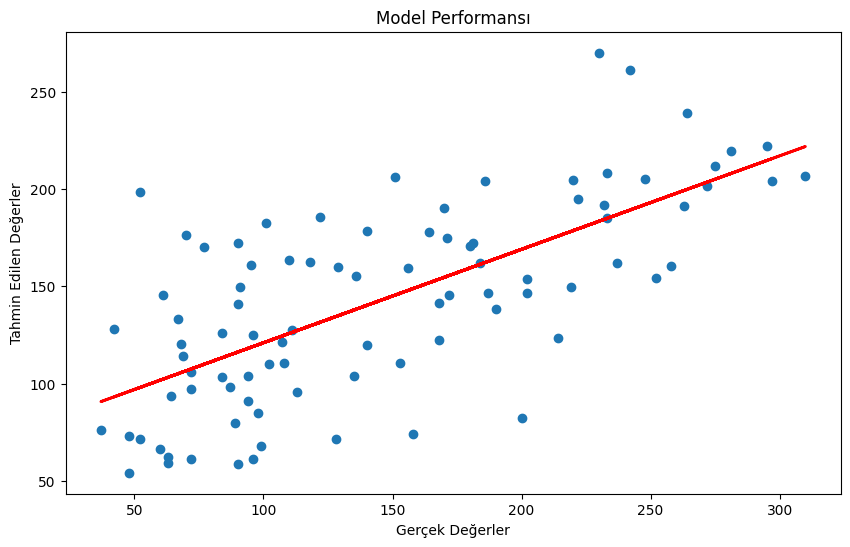

In [152]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1).fit(X_train, y_train)
pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, pred_lasso)
print(f"Lasso Regression Mean Squared Error: {mse_lasso:.3f}")
rmse_lasso = np.sqrt(mse_lasso)
print(f"Lasso Regression Root Mean Squared Error: {rmse_lasso:.3f} ({rmse_lasso/np.mean(pred_lasso)*100:.3f}%)")
r2_lasso = r2_score(y_test, pred_lasso)
print(f"Lasso Regression R^2 Skoru: {r2_lasso:.3f}")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_lasso)
z = np.polyfit(y_test, pred_lasso, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linewidth=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Model Performansı')
plt.show()

In [153]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'eta': 0.1,
    'seed': 42
}

model_xgb = xgb.train(params, dtrain, num_boost_round=100)
pred_xgb = model_xgb.predict(dtest)

mse_xgb = mean_squared_error(y_test, pred_xgb)
print(f"XGBoost Mean Squared Error: {mse_xgb:.3f}")
rmse_xgb = np.sqrt(mse_xgb)
print(f"XGBoost Root Mean Squared Error: {rmse_xgb:.3f} ({rmse_xgb/np.mean(pred_xgb)*100:.3f}%)")
r2_xgb = r2_score(y_test, pred_xgb)
print(f"XGBoost R^2 Skoru: {r2_xgb:.3f}")

XGBoost Mean Squared Error: 3326.303
XGBoost Root Mean Squared Error: 57.674 (38.821%)
XGBoost R^2 Skoru: 0.372


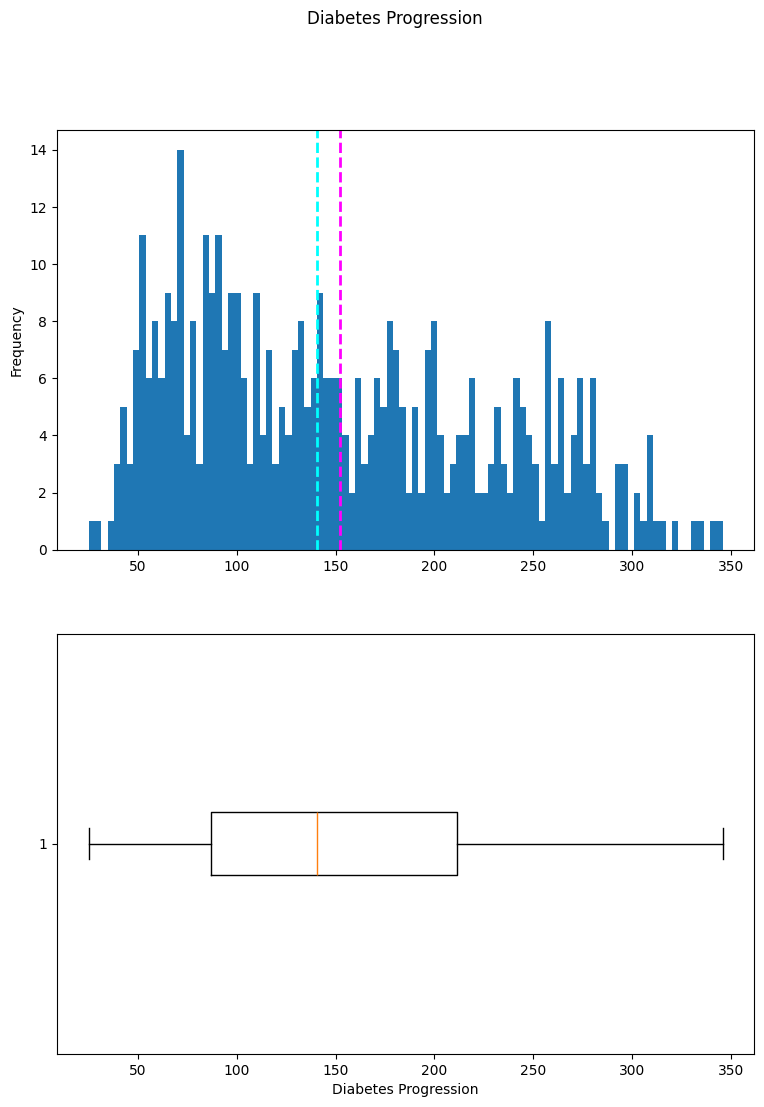

In [154]:
import pandas as pd
import matplotlib.pyplot as plt

# This ensures plots are displayed inline in the Jupyter notebook
%matplotlib inline

# Get the label column
label_m = df['dp']


# Create a figure for 2 subplots (2 rows, 1 column)
fig, ax = plt.subplots(2, 1, figsize = (9,12))

# Plot the histogram   
ax[0].hist(label_m, bins=100)
ax[0].set_ylabel('Frequency')

# Add lines for the mean, median, and mode
ax[0].axvline(label_m.mean(), color='magenta', linestyle='dashed', linewidth=2)
ax[0].axvline(label_m.median(), color='cyan', linestyle='dashed', linewidth=2)

# Plot the boxplot   
ax[1].boxplot(label_m, vert=False)
ax[1].set_xlabel('Diabetes Progression')

# Add a title to the Figure
plt.suptitle('Diabetes Progression')

# Show the figure
plt.show()


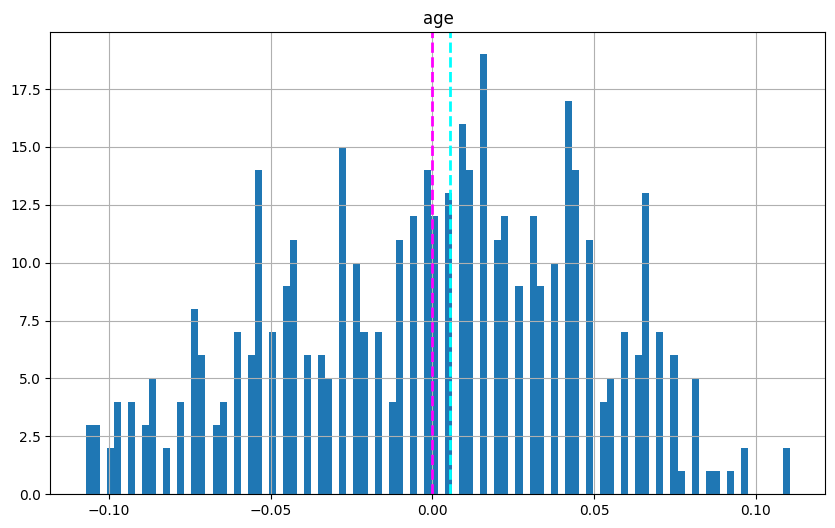

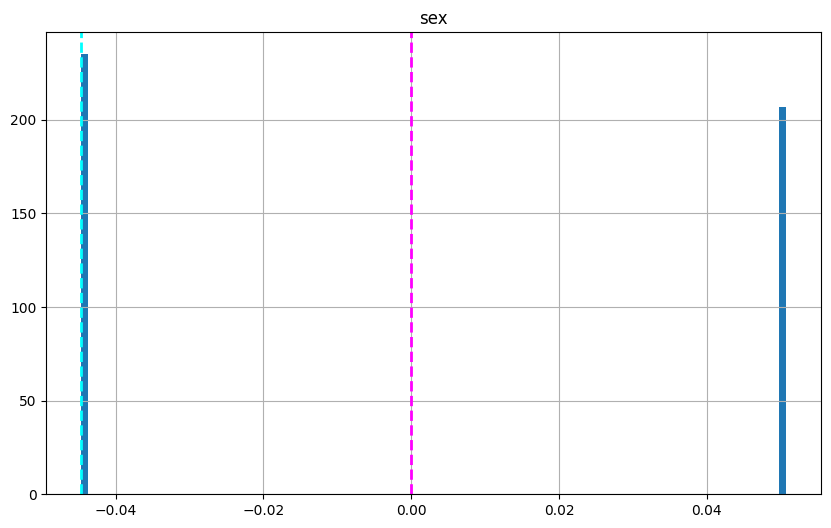

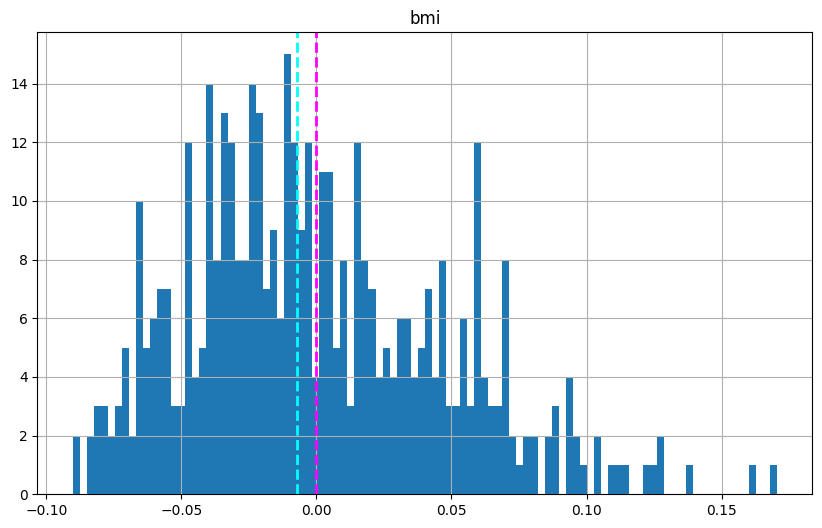

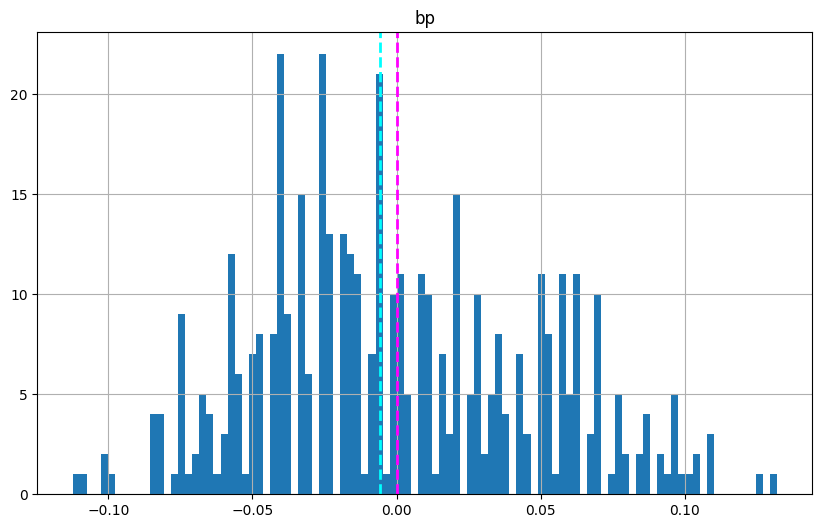

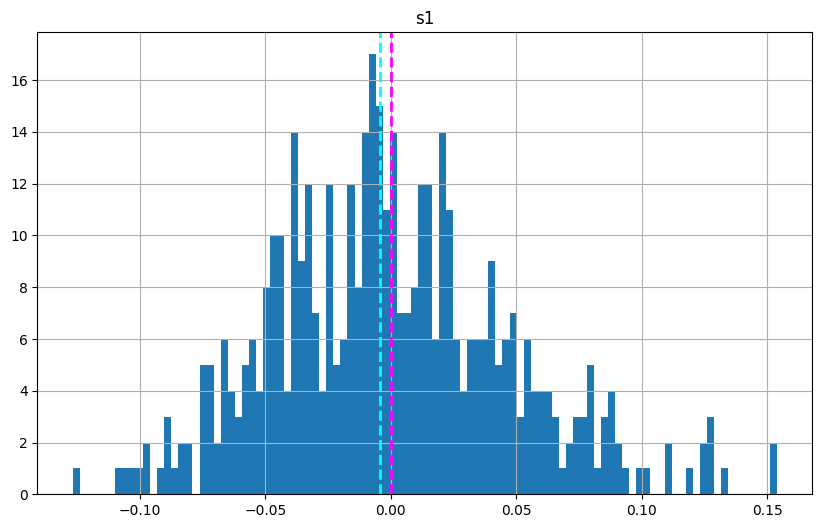

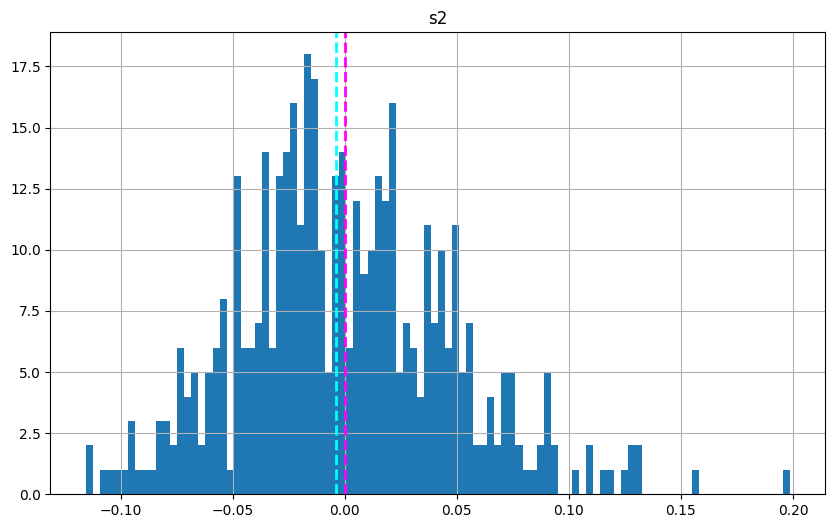

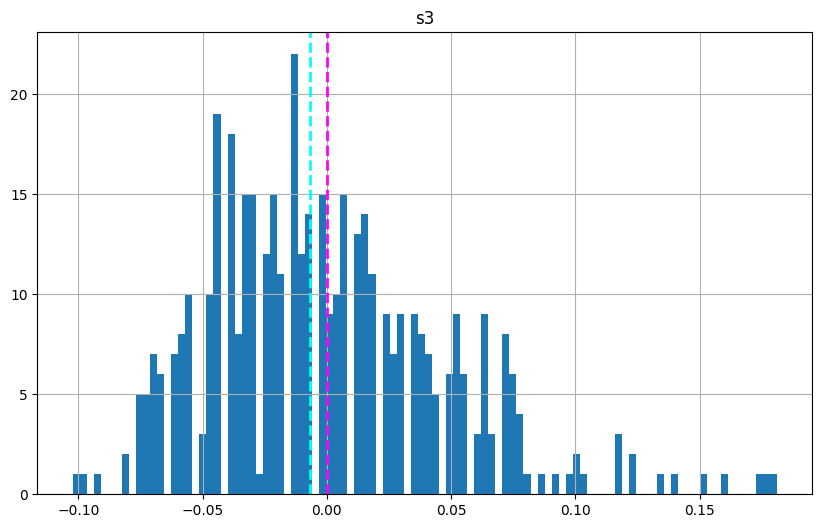

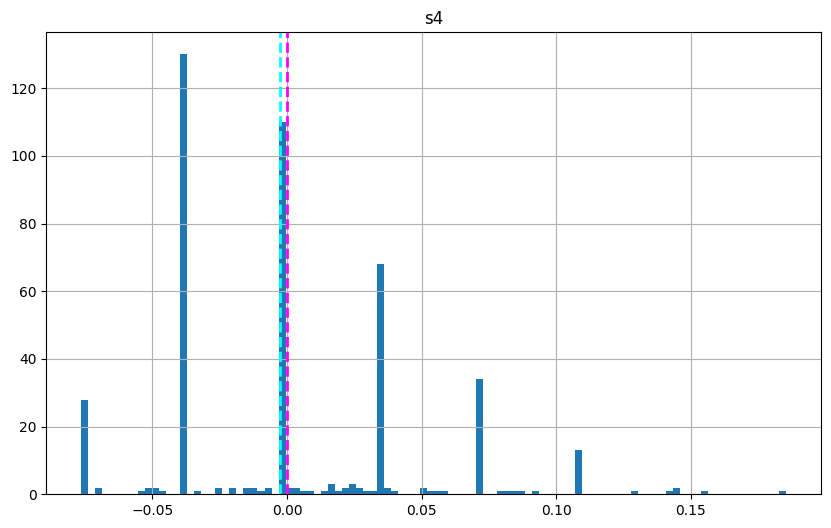

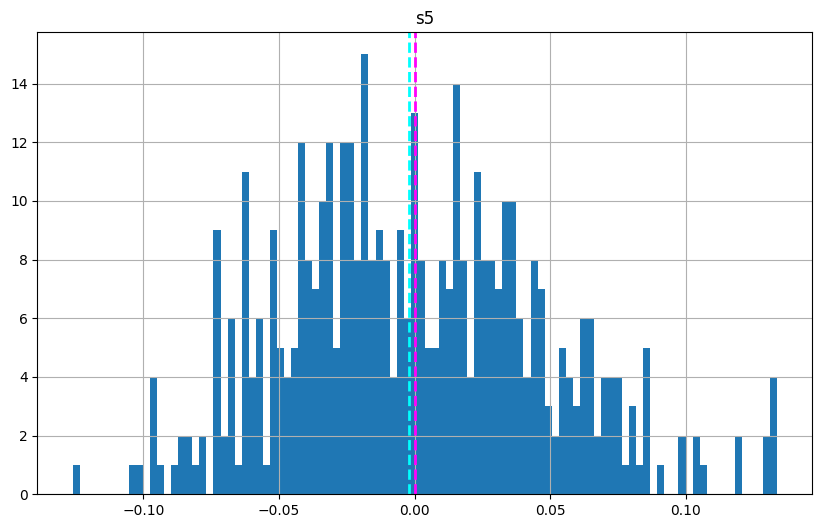

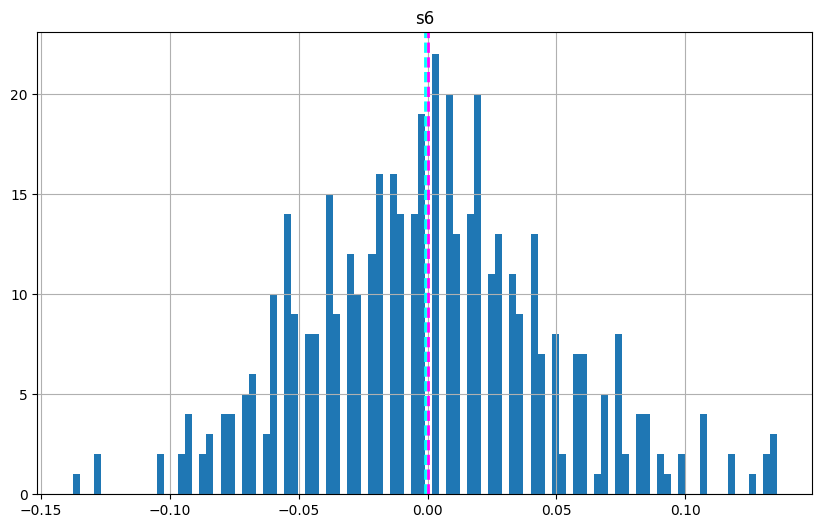

In [155]:
for col in df[features]:
    fig = plt.figure(figsize=(10, 6))
    ax = fig.gca()
    feature = df[col]
    feature.hist(bins=100, ax=ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()